## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.18 生成模型，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 22｜生成模型_自編碼器GAN與擴散

用線性欠完備自編碼器的等價案例 PCA 觀察壓縮與重建誤差。

對應 `slides/22_生成模型_自編碼器GAN與擴散.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/18_autoencoders_gans_and_diffusion_models.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Performing PCA with an Undercomplete Linear Autoencoder、Diffusion Models。

- `MachineLearning2025/04_PCA_from_scratch.py；04_SVD_from_scratch.py`，固定 commit `3da2cb56b9efd17d7cd34602589f392554b40603`。
- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
digits = load_digits()
X = digits.data / 16.0
pca = PCA(n_components=12, random_state=SEED).fit(X)
Z = pca.transform(X); recon = pca.inverse_transform(Z)
errors = np.mean((X-recon)**2, axis=1)
idx = [0, 1, int(np.argmax(errors))]
pd.DataFrame({'sample': idx, 'label': digits.target[idx], 'reconstruction_MSE': errors[idx]}).round(4)

,sample,label,reconstruction_MSE
0,0,0,0.0081
1,1,1,0.0162
2,1113,7,0.0639


## 執行結果圖

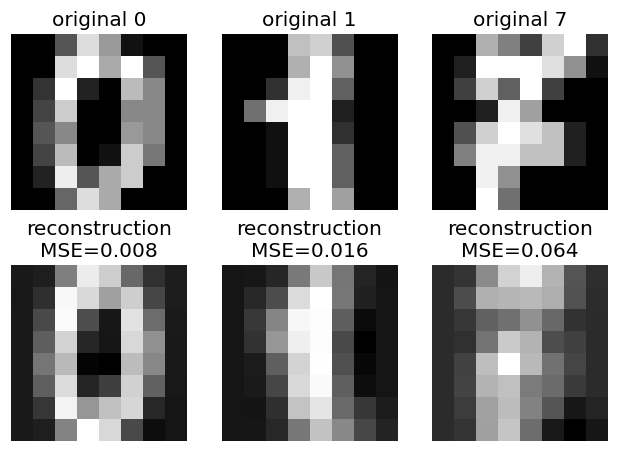

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
for col, i in enumerate(idx):
    axes[0,col].imshow(X[i].reshape(8,8), cmap='gray'); axes[0,col].set_title(f'original {digits.target[i]}')
    axes[1,col].imshow(recon[i].reshape(8,8), cmap='gray'); axes[1,col].set_title(f'reconstruction\nMSE={errors[i]:.3f}')
    axes[0,col].axis('off'); axes[1,col].axis('off')
savefig('22_generative_demo')
report('generative_models', {'components': 12, 'mean_MSE': errors.mean(), 'samples': idx})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。